# Introduction to Machine Learning - Milestone 2

1. Data Preparation

2. Models and Training

    2.1. Basic CNN

    - Training
    - Evaluation

    2.2. ResNet 50

    - Training
    - Evaluation

    2.3. MobileNetV2

    - Training
    - Evaluation
    
    2.4. VGG-style
    
    - Training
    - Evaluation

3. Model Comparison


# 1. Data Preparation

In [1]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

# basic algebra and system libraries
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as path
import pandas as pd
import gc
from tqdm import tqdm
import datetime
import seaborn as sns

# signal discrete fourier transform and loading
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import scipy.fft as fft

# audio preprocessing, cross-validation, and others
from sklearn.base import TransformerMixin, BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score

# construction of convolutional neural network
import keras
import keras.optimizers as optimizers
import keras.layers as layers
import keras.losses as losses
import keras.metrics as metrics
import keras.regularizers as regularizers
from tensorflow.keras import Input
from tensorflow.keras.callbacks import TensorBoard

# audio analysis
import librosa
import librosa.display

# processing speedup using GPU
import tensorflow as tf

# allow GPU computation to exceed system memory for a certain amount
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [3]:
# Load audio data paths and metadata
metadata = []
data_dir = os.path.join("..", "data", "raw")
class_1_speakers = ['f1', 'f7', 'f8', 'm3', 'm6', 'm8']

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".wav"):
            speaker_id = file.split('_')[0]
            label = 1 if speaker_id in class_1_speakers else 0
            metadata.append({
                'path': os.path.join(root, file),
                'label': label
            })

metadata_df = pd.DataFrame(metadata)
metadata_df.head()
len(metadata)

100

In [4]:
def load_and_split_audio(file_path, target_sr=16000, segment_length=1):
    # Load audio
    audio, sr = librosa.load(file_path, sr=target_sr)
    total_length = len(audio) / sr
    segments = []
    
    # Split audio into segments of length 'segment_length'
    for start in np.arange(0, total_length, segment_length):
        end = start + segment_length
        segment = audio[int(start*sr):int(end*sr)]
        # Pad if the segment is shorter
        if len(segment) < segment_length * sr:
            segment = np.pad(segment, (0, int(segment_length * sr) - len(segment)), mode='constant')
        segments.append(segment)
    return segments

def generate_spectrograms(segments, sr=16000):
    spectrograms = []
    for segment in segments:
        # Generate Mel Spectrogram
        S = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        S_DB = librosa.power_to_db(S, ref=np.max)
        spectrograms.append(S_DB)
    return spectrograms

# Apply load and split
metadata_df['segments'] = [load_and_split_audio(x) for x in tqdm(metadata_df['path'], desc="Loading and Splitting Audio Files")]
metadata_df = metadata_df.explode('segments')

# Generate spectrograms
metadata_df['spectrograms'] = [generate_spectrograms([x])[0] for x in tqdm(metadata_df['segments'], desc="Generating Spectrograms")]

print(f"Total number of spectrograms generated: {len(metadata_df)}")
metadata_df.head()

Generating Spectrograms: 100%|██████████| 16149/16149 [00:41<00:00, 387.87it/s]


Total number of spectrograms generated: 16149


,path,label,segments,spectrograms
0,../data/raw/m2_script5_cleanraw.wav,0,"[-0.00045567978, -0.00087706884, -0.0008387276...","[[-14.655068, -7.2121096, -4.3483057, -2.42628..."
0,../data/raw/m2_script5_cleanraw.wav,0,"[0.00013804888, 0.00010259588, 8.5510925e-05, ...","[[-6.615539, -2.5565867, -5.1238713, -4.038106..."
0,../data/raw/m2_script5_cleanraw.wav,0,"[8.196347e-05, 5.7751036e-05, 3.5946905e-05, 7...","[[-14.558612, -7.051508, -3.2473888, -2.600562..."
0,../data/raw/m2_script5_cleanraw.wav,0,"[-0.0011397437, -0.0011451175, -0.00118782, -0...","[[-10.213371, -7.9638453, -14.317848, -13.1445..."
0,../data/raw/m2_script5_cleanraw.wav,0,"[0.0016269071, 0.0016513073, 0.0016763688, 0.0...","[[-7.71115, -3.4734297, -1.1876097, -3.4024267..."


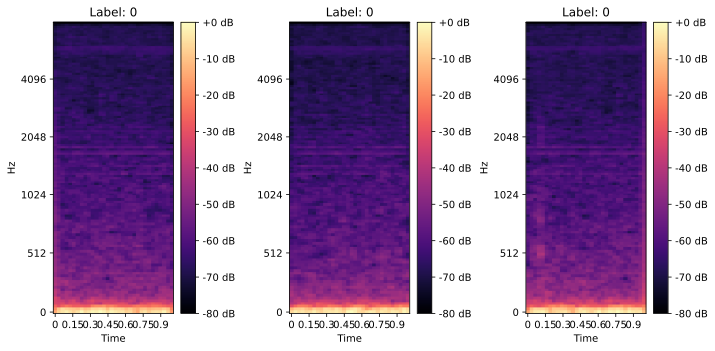

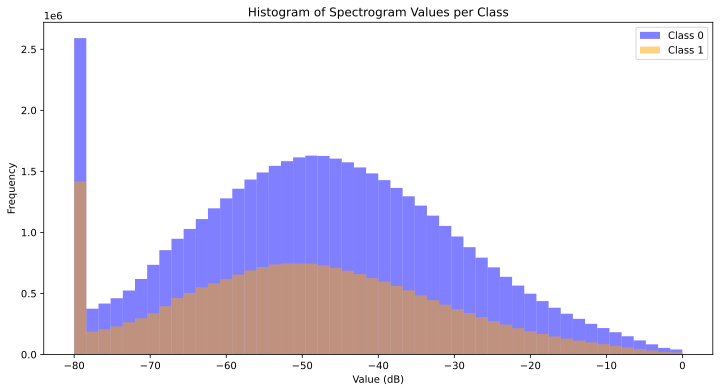

In [5]:
# Plot some example spectrograms
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    librosa.display.specshow(metadata_df.iloc[i]['spectrograms'], sr=16000, hop_length=512, x_axis='time', y_axis='mel')
    plt.title(f"Label: {metadata_df.iloc[i]['label']}")
    plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

# Histogram of spectrogram values per class
class_0_spectrograms = metadata_df[metadata_df['label'] == 0]['spectrograms'].values
class_1_spectrograms = metadata_df[metadata_df['label'] == 1]['spectrograms'].values

# Flatten spectrogram values
class_0_values = np.concatenate([s.ravel() for s in class_0_spectrograms])
class_1_values = np.concatenate([s.ravel() for s in class_1_spectrograms])

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(class_0_values, bins=50, alpha=0.5, label='Class 0', color='blue')
plt.hist(class_1_values, bins=50, alpha=0.5, label='Class 1', color='orange')
plt.title("Histogram of Spectrogram Values per Class")
plt.xlabel("Value (dB)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 2. Models and Training


## 2.1. Basic CNN

### Training

In [8]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create basic CNN model
def create_cnn():
    inputs = Input(shape=(128, 32, 1))
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

basic_cnn_model = create_cnn()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
basic_cnn_history = basic_cnn_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.5904 - loss: 0.8106 - val_accuracy: 0.7554 - val_loss: 0.4855
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.7819 - loss: 0.4415 - val_accuracy: 0.8554 - val_loss: 0.3099
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.8556 - loss: 0.3109 - val_accuracy: 0.8938 - val_loss: 0.2488
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9130 - loss: 0.2059 - val_accuracy: 0.9257 - val_loss: 0.1781
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9375 - loss: 0.1434 - val_accuracy: 0.9334 - val_loss: 0.1529
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9586 - loss: 0.1073 - val_accuracy: 0.9560 - val_loss: 0.1145
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9689 - loss: 0.0826 - val_accuracy: 0.9505 - val_loss: 0.1132
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9741 - loss: 0.0687 - 

### Evaluation

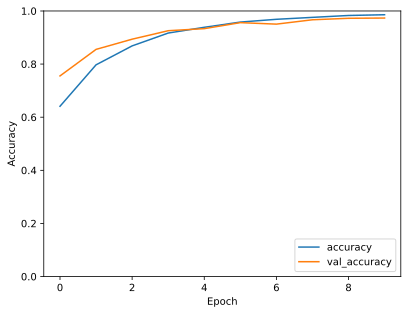

In [9]:
# Plot training history
plt.plot(basic_cnn_history.history['accuracy'], label='accuracy')
plt.plot(basic_cnn_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

## 2.2. ResNet 50

### Training

In [10]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create model
def create_resnet_for_spectrograms():
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights=None,  # Don't use ImageNet weights since input is different
        input_shape=(128, 32, 1),  # Your spectrogram shape
        pooling='avg'
    )
    
    # Modify first conv layer to accept single channel
    base_model.layers[0] = tf.keras.layers.Conv2D(
        64, 7, strides=2, padding='same',
        input_shape=(128, 32, 1)
    )
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


resnet_50_model = create_resnet_for_spectrograms()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
resnet_50_history = resnet_50_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

Epoch 1/10


/opt/miniconda3/envs/iml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


404/404 ━━━━━━━━━━━━━━━━━━━━ 191s 450ms/step - accuracy: 0.6156 - loss: 0.6729 - val_accuracy: 0.7350 - val_loss: 0.5312
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 210s 520ms/step - accuracy: 0.7952 - loss: 0.4266 - val_accuracy: 0.7461 - val_loss: 0.4879
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 215s 532ms/step - accuracy: 0.8625 - loss: 0.2935 - val_accuracy: 0.6879 - val_loss: 0.8981
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 261s 647ms/step - accuracy: 0.9028 - loss: 0.2172 - val_accuracy: 0.9139 - val_loss: 0.2295
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 256s 633ms/step - accuracy: 0.9399 - loss: 0.1506 - val_accuracy: 0.8601 - val_loss: 0.3885
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 198s 491ms/step - accuracy: 0.9369 - loss: 0.1512 - val_accuracy: 0.9043 - val_loss: 0.2524
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 199s 492ms/step - accuracy: 0.9613 - loss: 0.1004 - val_accuracy: 0.9372 - val_loss: 0.1731
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 199s 492ms/step - accuracy: 0.9652 - loss: 0.08

### Evaluation

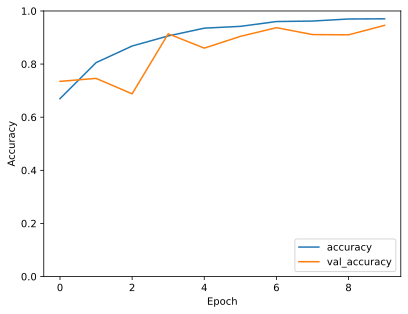

In [13]:
# Plot training history
plt.plot(resnet_50_history.history['accuracy'], label='accuracy')
plt.plot(resnet_50_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()


## 2.3. MobileNetV2

### Training

In [14]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create model
def create_mobilenetv2_for_spectrograms():
    # Create base MobileNetV2 model
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights=None,  # Don't use ImageNet weights since input is different
        input_shape=(128, 32, 1),
        alpha=1.0,  # Controls network width. Use smaller values (0.35, 0.5, 0.75) for faster inference
        pooling='avg'
    )
    
    # Modify first conv layer to accept single channel
    base_model.layers[0] = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=2, padding='same',
        input_shape=(128, 32, 1)
    )
    
    # Create the model
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


mobilenetv2_model = create_mobilenetv2_for_spectrograms()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
mobilenetv2_history = mobilenetv2_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

Epoch 1/10


/opt/miniconda3/envs/iml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


404/404 ━━━━━━━━━━━━━━━━━━━━ 51s 106ms/step - accuracy: 0.4961 - loss: 0.9698 - val_accuracy: 0.3087 - val_loss: 0.8564
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 105ms/step - accuracy: 0.5189 - loss: 0.8292 - val_accuracy: 0.3087 - val_loss: 0.8090
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - accuracy: 0.5273 - loss: 0.7839 - val_accuracy: 0.3087 - val_loss: 0.8073
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 105ms/step - accuracy: 0.5240 - loss: 0.7686 - val_accuracy: 0.3087 - val_loss: 0.7395
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.5440 - loss: 0.7401 - val_accuracy: 0.3087 - val_loss: 0.7285
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.5535 - loss: 0.7350 - val_accuracy: 0.3087 - val_loss: 0.7455
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 59s 145ms/step - accuracy: 0.5943 - loss: 0.6826 - val_accuracy: 0.6913 - val_loss: 0.6888
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 59s 145ms/step - accuracy: 0.6257 - loss: 0.6537 - val

### Evaluation

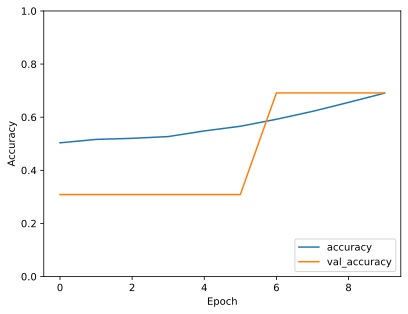

In [15]:
# Plot training history
plt.plot(mobilenetv2_history.history['accuracy'], label='accuracy')
plt.plot(mobilenetv2_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()


## 2.4. VGG-style

### Training

In [18]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create model
def create_vgg_for_spectrograms():
    model = tf.keras.Sequential([
        # Input layer
        tf.keras.layers.Input(shape=(128, 32, 1)),
        
        # First block
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Second block
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Third block
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Fourth block
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Dense layers
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


vgg_model = create_vgg_for_spectrograms()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
vgg_history = vgg_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)


Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 66s 160ms/step - accuracy: 0.6140 - loss: 0.6707 - val_accuracy: 0.8006 - val_loss: 0.4454
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 67s 166ms/step - accuracy: 0.7877 - loss: 0.4462 - val_accuracy: 0.8241 - val_loss: 0.3409
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 94s 234ms/step - accuracy: 0.8650 - loss: 0.3074 - val_accuracy: 0.8625 - val_loss: 0.2895
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 94s 232ms/step - accuracy: 0.9081 - loss: 0.2281 - val_accuracy: 0.9167 - val_loss: 0.1970
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 84s 207ms/step - accuracy: 0.9301 - loss: 0.1821 - val_accuracy: 0.9310 - val_loss: 0.1688
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.9402 - loss: 0.1503 - val_accuracy: 0.9412 - val_loss: 0.1438
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 81s 200ms/step - accuracy: 0.9505 - loss: 0.1278 - val_accuracy: 0.8759 - val_loss: 0.2705
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 78s 193ms/step - accuracy: 0.9629 - loss: 0

### Evaluation

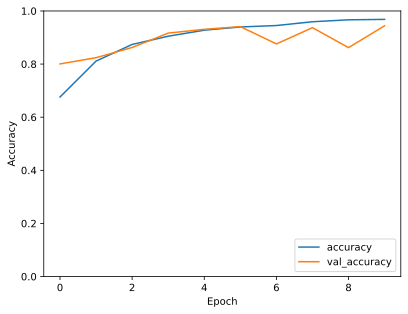

In [21]:
# Plot training history
plt.plot(vgg_history.history['accuracy'], label='accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()


# 3. Model Comparison

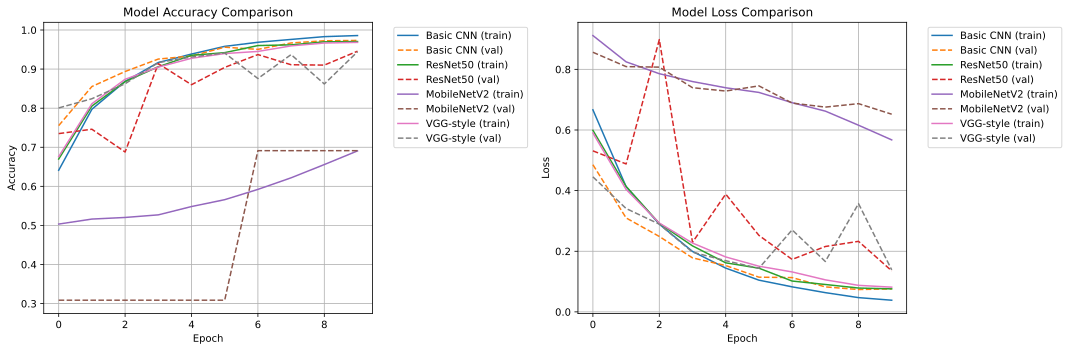

101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
  3/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step

/opt/miniconda3/envs/iml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


,Train Accuracy,Val Accuracy,Train Loss,Val Loss,F1 Score,Precision,Recall,Parameters
Model,,,,,,,,
Basic CNN,0.9858,0.9734,0.0385,0.0758,0.9567,0.9615,0.9519,"552,577"
ResNet50,0.9705,0.9458,0.0760,0.1353,0.9157,0.8813,0.9529,"24,083,329"
MobileNetV2,0.6908,0.6913,0.5673,0.6520,0.0000,0.0000,0.0000,"2,422,017"
VGG-style,0.9683,0.9443,0.0816,0.1385,0.9093,0.9139,0.9047,"379,777"


101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


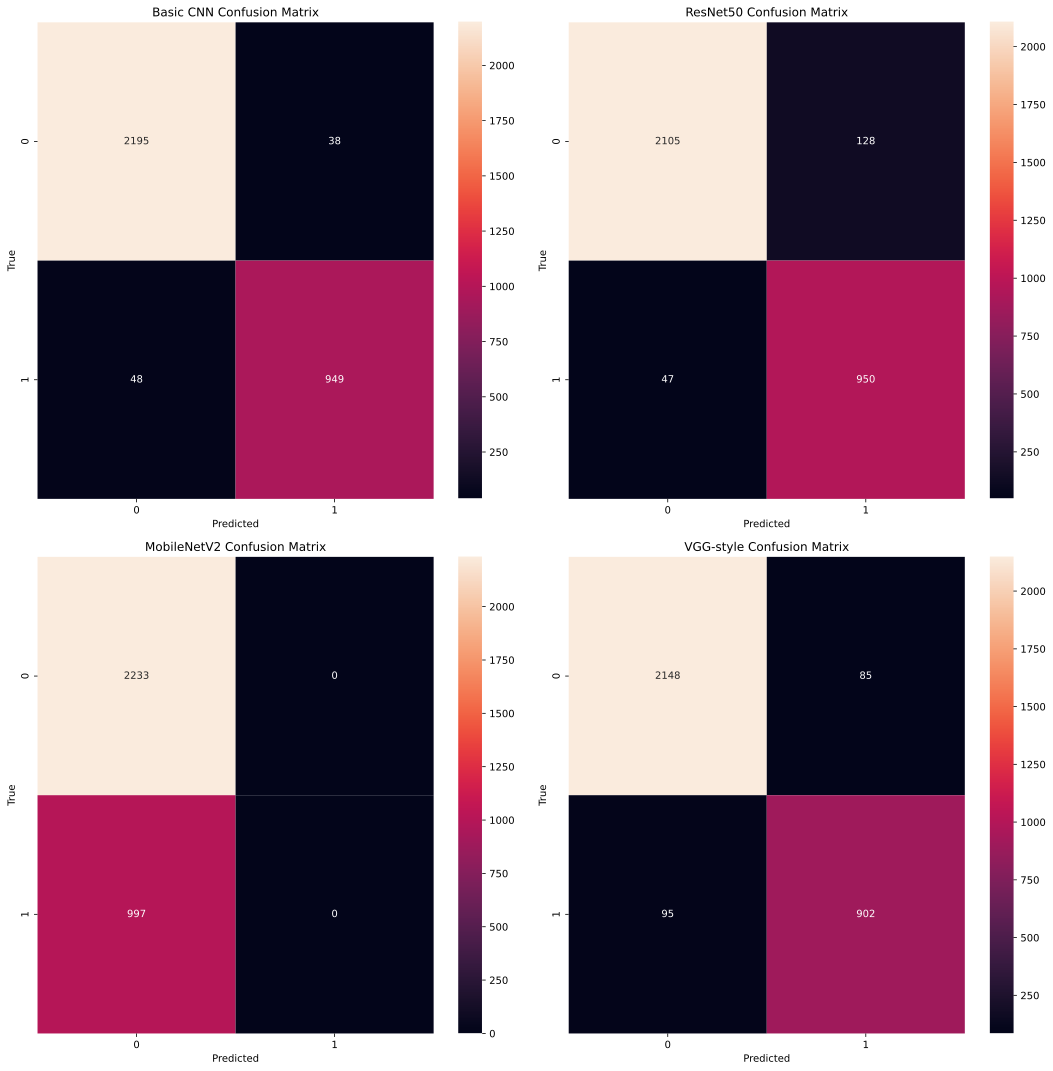

In [22]:
# Collect all model histories
histories = {
    'Basic CNN': basic_cnn_history,
    'ResNet50': resnet_50_history,
    'MobileNetV2': mobilenetv2_history,
    'VGG-style': vgg_history
}

# Create subplots for comparing metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training accuracy comparison
for model_name, history in histories.items():
    ax1.plot(history.history['accuracy'], label=f'{model_name} (train)')
    ax1.plot(history.history['val_accuracy'], label=f'{model_name} (val)', linestyle='--')

ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True)

# Plot training loss comparison
for model_name, history in histories.items():
    ax2.plot(history.history['loss'], label=f'{model_name} (train)')
    ax2.plot(history.history['val_loss'], label=f'{model_name} (val)', linestyle='--')

ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Create comparison table
models = {
    'Basic CNN': basic_cnn_model,
    'ResNet50': resnet_50_model,
    'MobileNetV2': mobilenetv2_model,
    'VGG-style': vgg_model
}

# Evaluate all models and collect metrics
results = []
for model_name, model in models.items():
    # Get final training and validation metrics
    final_train_acc = histories[model_name].history['accuracy'][-1]
    final_val_acc = histories[model_name].history['val_accuracy'][-1]
    final_train_loss = histories[model_name].history['loss'][-1]
    final_val_loss = histories[model_name].history['val_loss'][-1]
    
    # Get model size
    model_size = model.count_params()
    
    # Make predictions on test set
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    # Calculate additional metrics
    f1 = f1_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    
    results.append({
        'Model': model_name,
        'Train Accuracy': f'{final_train_acc:.4f}',
        'Val Accuracy': f'{final_val_acc:.4f}',
        'Train Loss': f'{final_train_loss:.4f}',
        'Val Loss': f'{final_val_loss:.4f}',
        'F1 Score': f'{f1:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'Parameters': f'{model_size:,}'
    })

# Create and display comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')
display(comparison_df)

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    cm = confusion_matrix(Y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx])
    axes[idx].set_title(f'{model_name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()